In [24]:
df = pd.read_excel("C:/xampp/htdocs/ai-drug-price/data/original_data_set/meds_price.xlsx")


In [25]:
df_clean = df.copy()
print("Base total rows:", len(df_clean))



Base total rows: 51216


In [26]:
text_columns = [
    "Generic Name",
    "Strength",
    "Pack Size",
    "Name of the Manufacturer",
    "Brand Name",
    "Dosage Description",
    "Use For"
]

for column in text_columns:
    df_clean[column] = df_clean[column].astype("string").str.strip()

In [38]:
duplicate_count = df_clean.duplicated().sum()
print("Duplicate rows:", duplicate_count)

# duplicates_all = df_clean[df_clean.duplicated(keep=False)].sort_values(by=list(df_clean.columns))
# duplicates_all
# df_clean.drop_duplicates(inplace=True)


Duplicate rows: 51


In [7]:



# Verify new shape/count
print("New total rows:", len(df_clean))
duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows:", duplicate_count)

New total rows: 51165
Duplicate rows: 0


In [8]:
missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100

print(missing_percentage)

Generic Name                0.0
Strength                    0.0
Pack Size                   0.0
Price                       0.0
Name of the Manufacturer    0.0
Brand Name                  0.0
Dosage Description          0.0
Use For                     0.0
dtype: float64


In [9]:
df_clean["Price"] = pd.to_numeric(
    df_clean["Price"],
    errors="coerce"
)

In [29]:
print(df_clean["Price"].dtype)
print("Zero prices:", (df_clean["Price"] == 0).sum())
print("Negative prices:", (df_clean["Price"] < 0).sum())
print("Missing prices:", df_clean["Price"].isnull().sum())

float64
Zero prices: 0
Negative prices: 0
Missing prices: 0


In [33]:
print(df_clean["Price"].describe(percentiles=[
    .75, .85, .95, .96, .97, .98, .99
]))


count     51216.000000
mean        107.578798
std        1153.315032
min           0.100000
75%          35.110000
85%          75.000000
95%         280.000000
96%         370.000000
97%         511.330000
98%         800.000000
99%        1303.910000
max      126000.000000
Name: Price, dtype: float64


In [35]:
df_clean = df_clean[df_clean["Price"] <= 800].copy()
print("Remaining rows:", len(df_clean))
print("Maximum price:", df_clean["Price"].max())

Remaining rows: 50198
Maximum price: 800.0


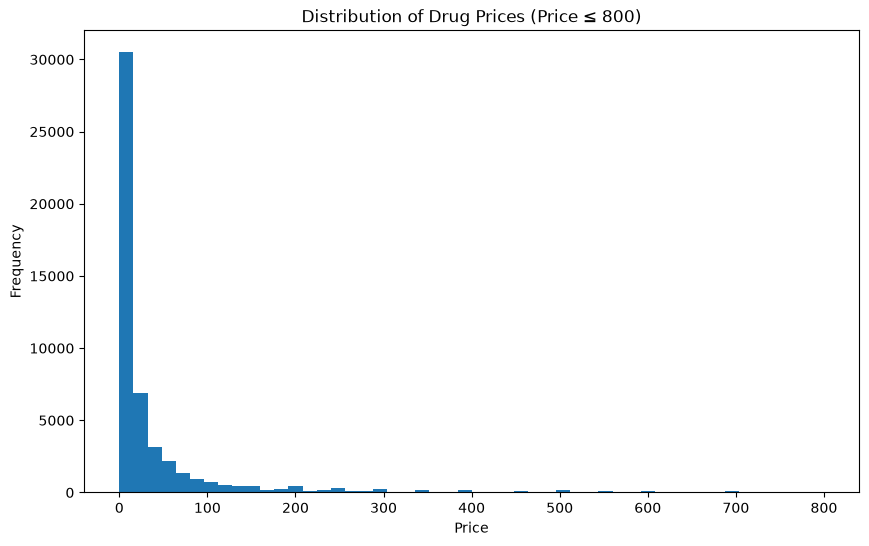

In [37]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean[df_clean["Price"] <= 800]["Price"], bins=50)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Drug Prices (Price ≤ 800)")

plt.show()



In [41]:
bins = [0, 10, 20, 30, 40, 50, 75, 100, 200, 500, 800]

hist_table = pd.cut(
    df_clean["Price"],
    bins=bins,
    include_lowest=True
).value_counts().sort_index()
print(hist_table)

Price
(-0.001, 10.0]    23358
(10.0, 20.0]       9535
(20.0, 30.0]       4029
(30.0, 40.0]       2537
(40.0, 50.0]       1881
(50.0, 75.0]       2232
(75.0, 100.0]      1850
(100.0, 200.0]     2456
(200.0, 500.0]     1773
(500.0, 800.0]      547
Name: count, dtype: int64


In [43]:
output_file = "C:/xampp/htdocs/ai-drug-price/data/cleaned_data_set/cleaned.csv"
df_clean.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)
print("Saved:", output_file)
print("Final shape:", df_clean.shape)

Saved: C:/xampp/htdocs/ai-drug-price/data/cleaned_data_set/cleaned.csv
Final shape: (50198, 8)
